# 05. Biological interpretation and report materials

このノートブックは、gene mapping routeで作ったDESeq2の結果を、生物学的な解釈とレポート材料に整理する段階である。

**このノートブックの役割**

- volcano plot、DEGリスト、top DEG heatmapを作り、変化の大きい遺伝子を確認する。
- DEGやサンプルのクラスタリングから、発現パターンのまとまりを読む。
- 必要に応じてGO enrichment / GSEAを実行し、結果を図とreport indexにまとめる。

**入力**

- `results/gene_mapping/de/deseq2_<contrast_id>.csv`（各contrastのDESeq2結果）
- `results/gene_mapping/de/deseq2_normalized_counts.tsv`（top DEG heatmapで使う補正済みcount）
- `results/gene_mapping/de/deseq2_vst_counts.tsv`（サンプル/DEGクラスタリングで使うVST変換値）
- `metadata/samples.tsv`（sample_id、condition、replicateを持つsample metadata）
- `metadata/contrasts.tsv`（表示対象のcontrast一覧）

**出力**

- `results/gene_mapping/report/volcano_<contrast_id>.png`
- `results/gene_mapping/report/deg_<contrast_id>.csv` と `results/gene_mapping/report/deg_summary.tsv`
- `results/gene_mapping/report/heatmap_top_deg_<contrast_id>.png`
- `results/gene_mapping/report/clustermap_deg_<contrast_id>.png` と `results/gene_mapping/report/deg_clusters_<contrast_id>.tsv`
- `results/gene_mapping/enrichment/<contrast_id>/`（optional GO enrichment / GSEAの出力）
- `results/gene_mapping/report/report_index.md`

**次に進む条件**

- DEGリストと図の向きが、`contrasts.tsv` のtest/referenceの定義と一致している。
- enrichment結果は仮説生成として扱い、単独で因果や機序の証明として読まない。


In [2]:
from pathlib import Path
import json
import shutil
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path("/Users/yusuke_tateishi/Documents/RNA_seq").resolve()
CONFIG = json.loads((PROJECT_DIR / "config" / "analysis_config.json").read_text(encoding="utf-8"))
SAMPLES = pd.read_csv(PROJECT_DIR / CONFIG["samples_path"], sep="\t")
CONTRASTS = pd.read_csv(PROJECT_DIR / CONFIG["contrasts_path"], sep="\t")
DE_DIR = PROJECT_DIR / "results/gene_mapping/de"
REPORT_DIR = PROJECT_DIR / "results/gene_mapping/report"
ENRICHMENT_DIR = PROJECT_DIR / "results/gene_mapping/enrichment"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
ENRICHMENT_DIR.mkdir(parents=True, exist_ok=True)

CONTRASTS

ROUTE_NAME = "gene mapping route"
ROUTE_QUANTIFICATION = "STAR genome mapping + featureCounts"
ROUTE_QUANTIFICATION_OUTPUT = "results/quant/genome_mapping/"
ROUTE_COUNT_MATRIX = "results/counts/gene_counts_genome_mapping.tsv"
ROUTE_SAMPLE_QC_DIR = "results/gene_mapping/sample_qc/"
ROUTE_DE_DIR = "results/gene_mapping/de/"
ROUTE_REPORT_DIR = "results/gene_mapping/report/"
ROUTE_ENRICHMENT_DIR = "results/gene_mapping/enrichment/"

CONTRASTS


,contrast_id,test_condition,reference_condition,description
0,Oxi_2h_vs_Non,Oxi_2h,Non,Oxidative stress at 2h compared with untreated...
1,NAC_S2_2h_vs_Non,NAC_S2_2h,Non,NAC_S2 at 2h compared with untreated control
2,NAC_S2_2h_vs_Oxi_2h,NAC_S2_2h,Oxi_2h,NAC_S2 at 2h compared with oxidative stress at 2h


## volcano plot

volcano plotは、横軸に変化量、縦軸に有意性を置いた図である。

- 右側: test conditionで上がる遺伝子。
- 左側: test conditionで下がる遺伝子。
- 上側: 統計的に強い遺伝子。


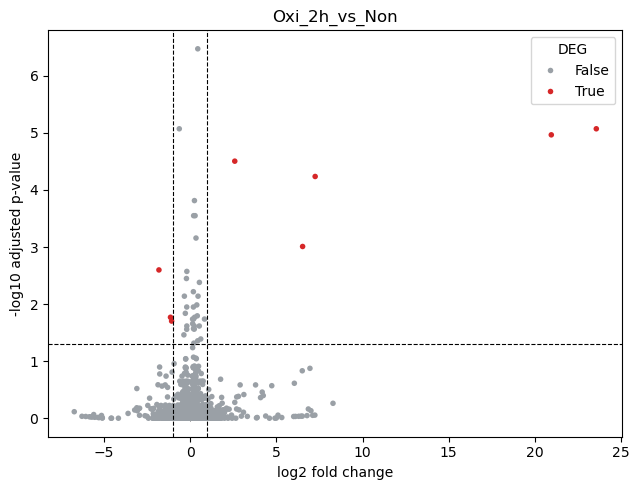

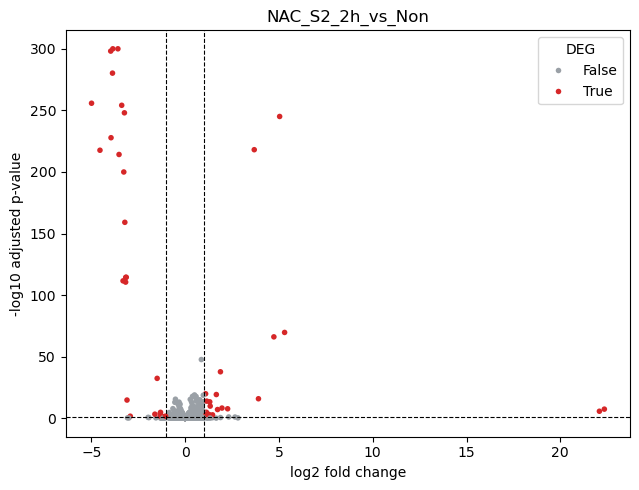

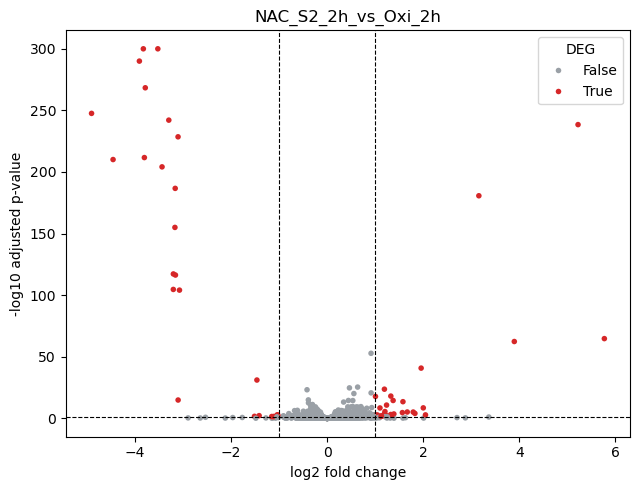

In [6]:
ALPHA = float(CONFIG["differential_expression"]["alpha"])
LFC_THRESHOLD = float(CONFIG["differential_expression"]["lfc_threshold"])

def load_de_result(contrast_id: str) -> pd.DataFrame:
    path = DE_DIR / f"deseq2_{contrast_id}.csv"
    if not path.exists():
        raise FileNotFoundError(f"DESeq2 result not found: {path}. Run notebook 04 first.")
    de = pd.read_csv(path)
    de["minus_log10_padj"] = -np.log10(de["padj"].clip(lower=1e-300))
    de["is_deg"] = (de["padj"] < ALPHA) & (de["log2FoldChange"].abs() >= LFC_THRESHOLD)
    return de

for contrast_id in CONTRASTS["contrast_id"]:
    try:
        de = load_de_result(contrast_id)
    except FileNotFoundError as exc:
        print(exc)
        continue

    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.scatterplot(
        data=de,
        x="log2FoldChange",
        y="minus_log10_padj",
        hue="is_deg",
        palette={False: "#9aa0a6", True: "#d62728"},
        s=16,
        linewidth=0,
        ax=ax,
    )
    ax.axvline(LFC_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
    ax.axvline(-LFC_THRESHOLD, color="black", linestyle="--", linewidth=0.8)
    ax.axhline(-np.log10(ALPHA), color="black", linestyle="--", linewidth=0.8)
    ax.set_title(contrast_id)
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.legend(title="DEG", loc="upper right")
    plt.tight_layout()
    out_path = REPORT_DIR / f"volcano_{contrast_id}.png"
    plt.savefig(out_path, dpi=160)
    plt.show()


## DEGリストを書き出す

DEGリストは最終回答ではなく、解釈の材料である。ここではup/downに分けて保存する。


In [11]:
deg_summaries = []
for contrast_id in CONTRASTS["contrast_id"]:
    path = DE_DIR / f"deseq2_{contrast_id}.csv"
    if not path.exists():
        continue
    de = pd.read_csv(path)
    deg = de[(de["padj"] < ALPHA) & (de["log2FoldChange"].abs() >= LFC_THRESHOLD)].copy()
    deg = deg.sort_values(["padj", "log2FoldChange"], ascending=[True, False])
    deg.to_csv(REPORT_DIR / f"deg_{contrast_id}.csv", index=False)
    deg_summaries.append(
        {
            "contrast_id": contrast_id,
            "deg_total": len(deg),
            "up": int((deg["log2FoldChange"] > 0).sum()),
            "down": int((deg["log2FoldChange"] < 0).sum()),
        }
    )

if deg_summaries:
    deg_summary = pd.DataFrame(deg_summaries)
    deg_summary.to_csv(REPORT_DIR / "deg_summary.tsv", sep="\t", index=False)
    display(deg_summary)
else:
    print("No DEG outputs yet.")


,contrast_id,deg_total,up,down
0,Oxi_2h_vs_Non,8,5,3
1,NAC_S2_2h_vs_Non,53,28,25
2,NAC_S2_2h_vs_Oxi_2h,59,34,25


## top DEG（Differentially Expressed Gene） heatmap

normalized countsがある場合、変化の大きい遺伝子をheatmapで見る。これは「各群で本当に一貫した変化があるか」を目で確認するためである。


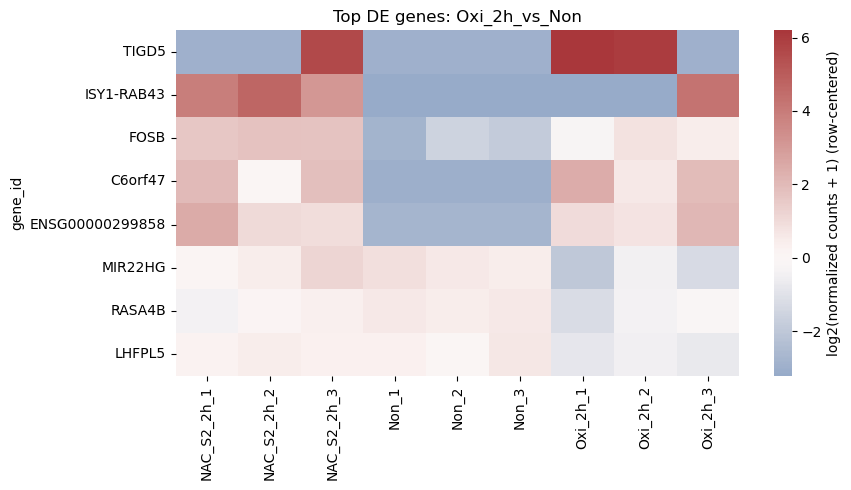

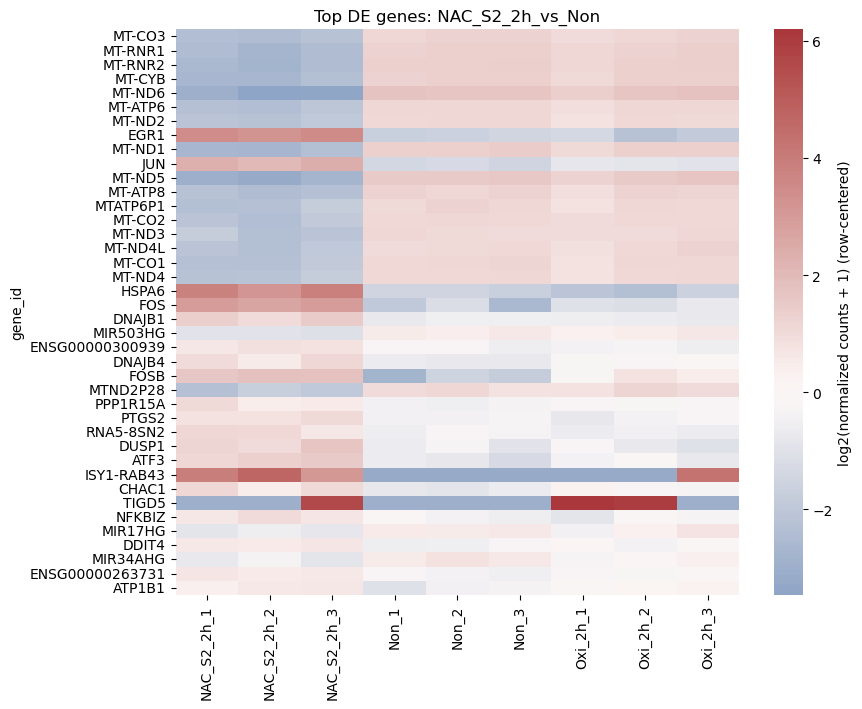

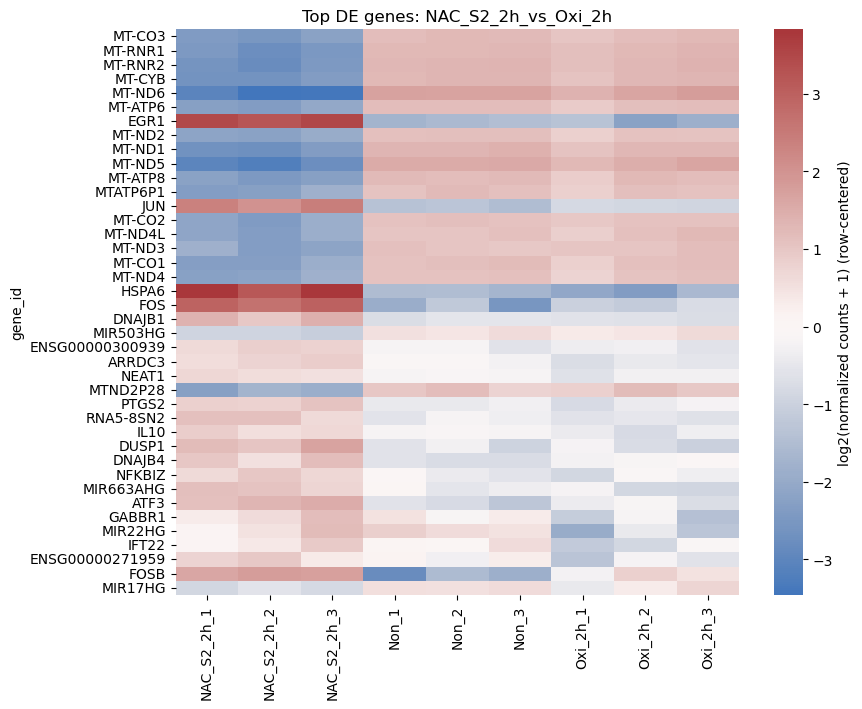

In [12]:
normalized_counts_path = DE_DIR / "deseq2_normalized_counts.tsv"

if normalized_counts_path.exists():
    normalized_counts = pd.read_csv(normalized_counts_path, sep="\t").set_index("gene_id")
    for contrast_id in CONTRASTS["contrast_id"]:
        deg_path = REPORT_DIR / f"deg_{contrast_id}.csv"
        if not deg_path.exists():
            continue
        deg = pd.read_csv(deg_path)
        top_gene_ids = deg.head(40)["gene_id"].tolist()
        top_gene_ids = [gene_id for gene_id in top_gene_ids if gene_id in normalized_counts.index]
        if not top_gene_ids:
            continue
        matrix = np.log2(normalized_counts.loc[top_gene_ids, SAMPLES["sample_id"]] + 1)
        matrix = matrix.sub(matrix.mean(axis=1), axis=0)
        plt.figure(figsize=(9, max(5, len(top_gene_ids) * 0.18)))
        sns.heatmap(matrix, cmap="vlag", center=0, yticklabels=True, cbar_kws={'label': 'log2(normalized counts + 1) (row-centered)'})
        plt.title(f"Top DE genes: {contrast_id}")
        plt.tight_layout()
        plt.savefig(REPORT_DIR / f"heatmap_top_deg_{contrast_id}.png", dpi=160)
        plt.show()
else:
    print("No normalized counts yet. Run notebook 04 first.")


## サンプルの階層的クラスタリング

PCAはサンプル関係を2次元で見る方法であった。階層的クラスタリングは、サンプル同士の距離を計算して、近いサンプルから枝分かれ図としてまとめる。

ここではDESeq2の `vst` 正規化値を使い、変動の大きい上位1000遺伝子でサンプルをクラスタリングする。

読み方は単純である。同じconditionのreplicateが近くに集まれば、サンプル構造は比較的きれいである。`Non` と `Oxi_2h` が近く、`NAC_S2_2h` が別にまとまるなら、PCAで見えた構造と整合する。


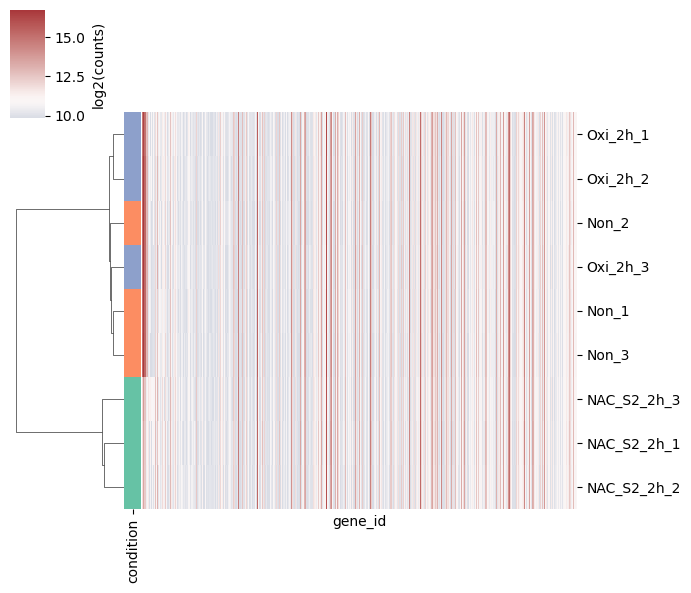

Sample cluster order:


,cluster_order,sample_id,condition,replicate
0,1,Oxi_2h_1,Oxi_2h,1
1,2,Oxi_2h_2,Oxi_2h,2
2,3,Non_2,Non,2
3,4,Oxi_2h_3,Oxi_2h,3
4,5,Non_1,Non,1
5,6,Non_3,Non,3
6,7,NAC_S2_2h_3,NAC_S2_2h,3
7,8,NAC_S2_2h_1,NAC_S2_2h,1
8,9,NAC_S2_2h_2,NAC_S2_2h,2


Wrote: results/report/sample_hierarchical_clustering_vst_top1000.png


In [13]:
vst_counts_path = DE_DIR / "deseq2_vst_counts.tsv"
sample_cluster_path = REPORT_DIR / "sample_hierarchical_clustering_vst_top1000.png"
sample_order_path = REPORT_DIR / "sample_hierarchical_clustering_order.tsv"

if vst_counts_path.exists():
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist

    vst_counts = pd.read_csv(vst_counts_path, sep="\t").set_index("gene_id")
    vst_counts = vst_counts[SAMPLES["sample_id"]]

    top_variable_genes = vst_counts.var(axis=1).sort_values(ascending=False).head(1000).index
    sample_matrix = vst_counts.loc[top_variable_genes].T

    sample_linkage = linkage(pdist(sample_matrix, metric="correlation"), method="average")
    sample_order = [sample_matrix.index[i] for i in leaves_list(sample_linkage)]
    pd.DataFrame({"cluster_order": range(1, len(sample_order) + 1), "sample_id": sample_order}).merge(
        SAMPLES[["sample_id", "condition", "replicate"]],
        on="sample_id",
        how="left",
    ).to_csv(sample_order_path, sep="\t", index=False)

    condition_palette = dict(zip(SAMPLES["condition"].unique(), sns.color_palette("Set2", n_colors=SAMPLES["condition"].nunique())))
    sample_colors = SAMPLES.set_index("sample_id").loc[sample_matrix.index, "condition"].map(condition_palette)

    grid = sns.clustermap(
        sample_matrix,
        row_linkage=sample_linkage,
        col_cluster=False,
        row_colors=sample_colors,
        cmap="vlag",
        center=sample_matrix.to_numpy().mean(),
        xticklabels=False,
        yticklabels=True,
        figsize=(7, 6),
        cbar_kws={'label': 'log2(counts)'}
    )
    #grid.subtitle("Sample hierarchical clustering: VST top variable genes", y=1.02)
    grid.savefig(sample_cluster_path, dpi=180, bbox_inches="tight")
    plt.show()

    print("Sample cluster order:")
    display(pd.read_csv(sample_order_path, sep="\t"))
    print("Wrote:", sample_cluster_path.relative_to(PROJECT_DIR))
else:
    print("No VST counts yet. Run notebook 04 first.")


## DEGの階層的クラスタリング

次に、各比較でDEGになった遺伝子だけを取り出し、発現パターンでクラスタリングする。

ここではgeneごとに平均0、標準偏差1へ変換した値を使う。これにより「発現量が大きい遺伝子」ではなく、「どのサンプルで相対的に高いか/低いか」というパターンを見る。

出力される `deg_clusters_<contrast>.tsv` は、各DEGがどのクラスタに入ったかを示す表である。たとえば、NAC_S2で上がるクラスタ、NAC_S2で下がるクラスタを読む材料になる。


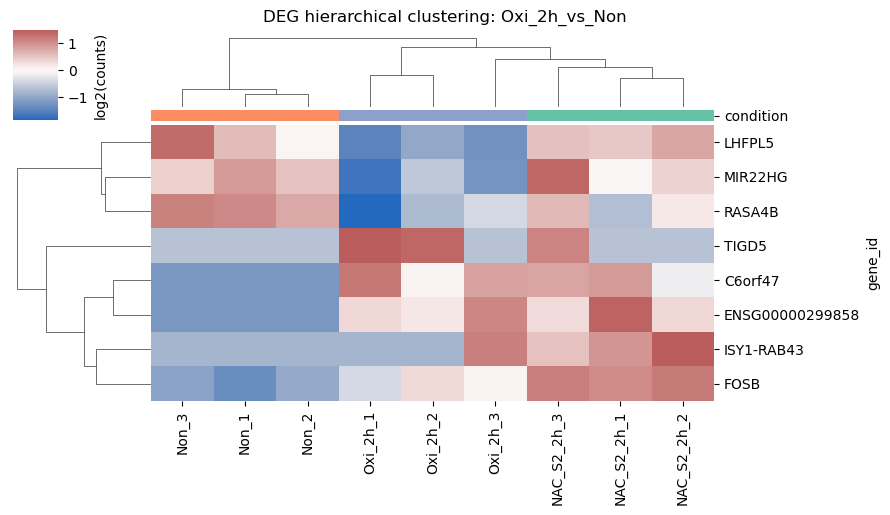

Wrote: results/report/clustermap_deg_Oxi_2h_vs_Non.png


,cluster,direction,n_genes
0,1,down,3
1,2,up,5


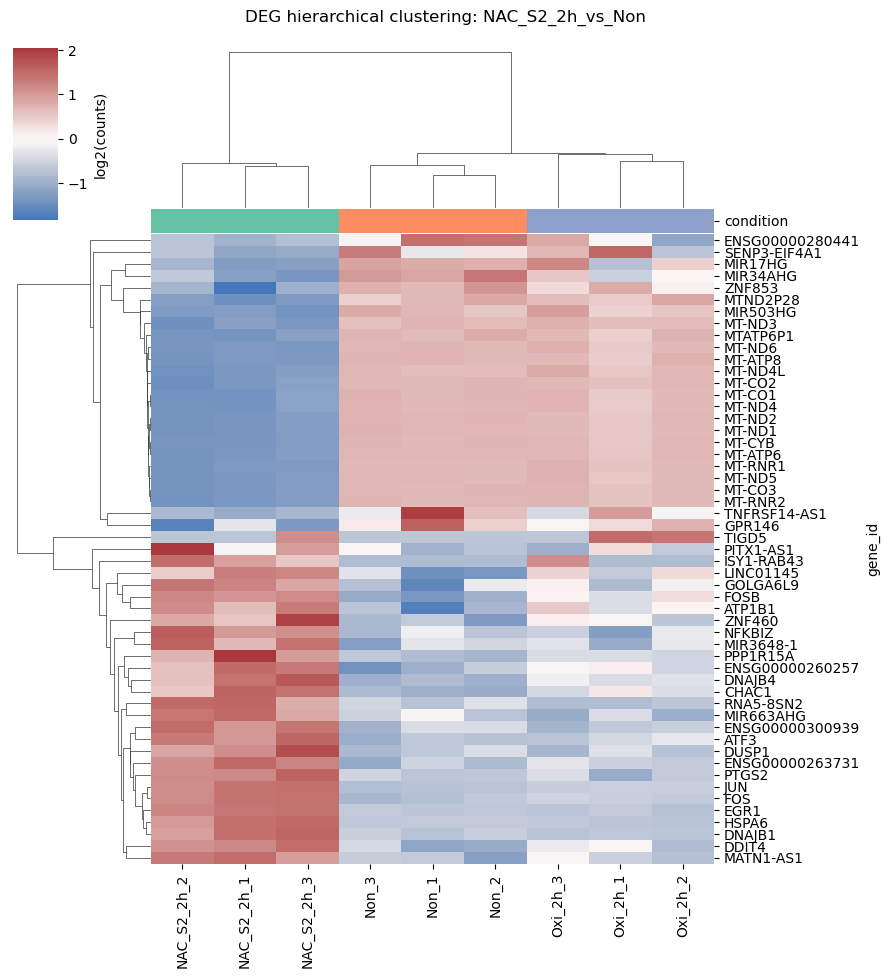

Wrote: results/report/clustermap_deg_NAC_S2_2h_vs_Non.png


,cluster,direction,n_genes
0,1,down,25
1,2,up,28


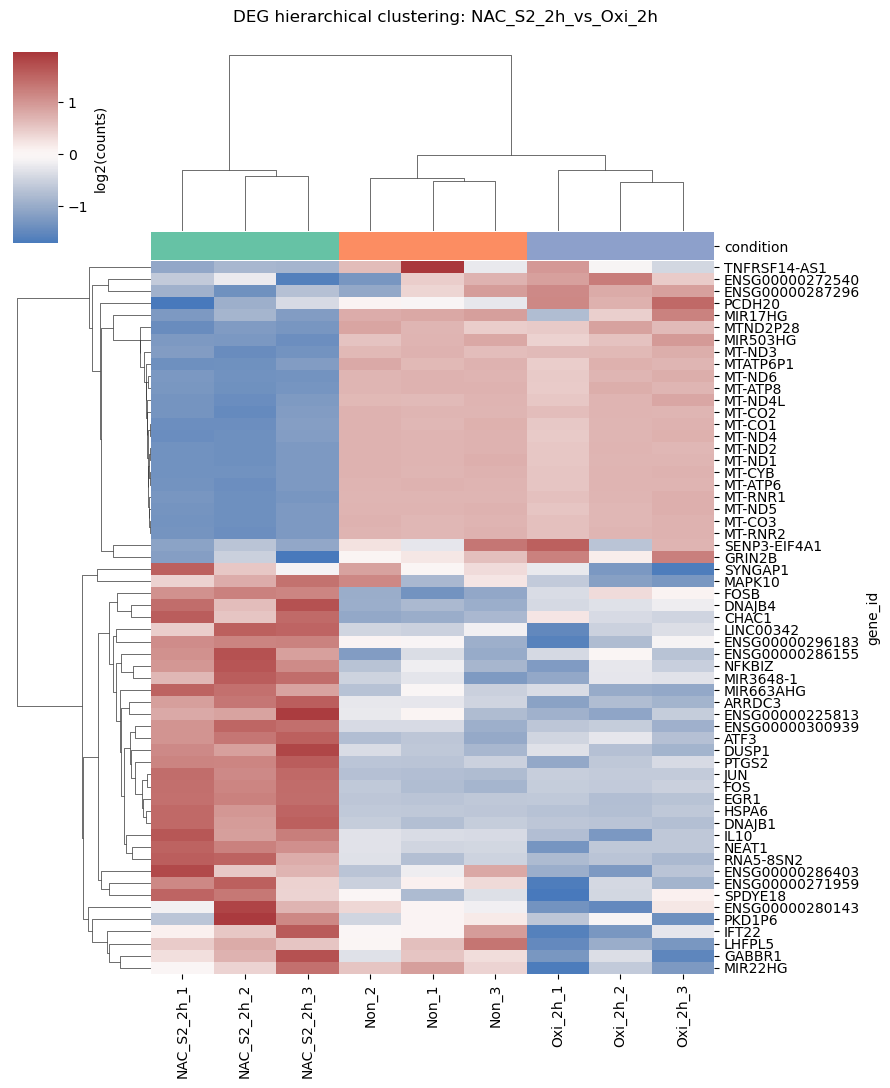

Wrote: results/report/clustermap_deg_NAC_S2_2h_vs_Oxi_2h.png


,cluster,direction,n_genes
0,1,down,25
1,2,up,34


In [14]:
if vst_counts_path.exists():
    from scipy.cluster.hierarchy import linkage, fcluster
    from scipy.spatial.distance import pdist

    vst_counts = pd.read_csv(vst_counts_path, sep="\t").set_index("gene_id")
    vst_counts = vst_counts[SAMPLES["sample_id"]]
    condition_palette = dict(zip(SAMPLES["condition"].unique(), sns.color_palette("Set2", n_colors=SAMPLES["condition"].nunique())))
    column_colors = SAMPLES.set_index("sample_id").loc[vst_counts.columns, "condition"].map(condition_palette)

    for contrast_id in CONTRASTS["contrast_id"]:
        deg_path = REPORT_DIR / f"deg_{contrast_id}.csv"
        if not deg_path.exists():
            print("Skipping missing DEG file:", deg_path.relative_to(PROJECT_DIR))
            continue

        deg = pd.read_csv(deg_path)
        deg_gene_ids = [gene_id for gene_id in deg["gene_id"].tolist() if gene_id in vst_counts.index]
        if len(deg_gene_ids) < 2:
            print(f"Skipping {contrast_id}: fewer than 2 DEG genes available for clustering.")
            continue

        matrix = vst_counts.loc[deg_gene_ids]
        z_matrix = matrix.sub(matrix.mean(axis=1), axis=0).div(matrix.std(axis=1).replace(0, np.nan), axis=0).fillna(0)

        row_linkage = linkage(pdist(z_matrix, metric="euclidean"), method="average")
        cluster_labels = fcluster(row_linkage, t=2, criterion="maxclust")
        cluster_table = pd.DataFrame({"gene_id": z_matrix.index, "cluster": cluster_labels}).merge(
            deg[["gene_id", "log2FoldChange", "padj", "direction"]],
            on="gene_id",
            how="left",
        )
        cluster_table.to_csv(REPORT_DIR / f"deg_clusters_{contrast_id}.tsv", sep="\t", index=False)

        grid = sns.clustermap(
            z_matrix,
            row_linkage=row_linkage,
            col_cluster=True,
            col_colors=column_colors,
            cmap="vlag",
            center=0,
            yticklabels=True if len(deg_gene_ids) <= 80 else False,
            xticklabels=True,
            figsize=(9, max(5, len(deg_gene_ids) * 0.18)),
            cbar_kws={'label': 'log2(counts)'}
        )
        grid.fig.suptitle(f"DEG hierarchical clustering: {contrast_id}", y=1.02)
        out_path = REPORT_DIR / f"clustermap_deg_{contrast_id}.png"
        grid.savefig(out_path, dpi=180, bbox_inches="tight")
        plt.show()

        print("Wrote:", out_path.relative_to(PROJECT_DIR))
        display(cluster_table.groupby(["cluster", "direction"]).size().reset_index(name="n_genes"))
else:
    print("No VST counts yet. Run notebook 04 first.")


## clusterProfiler enrichment

これは「DEGがどんな機能に偏っているか」を見る解析である。
GSEA（Gene Set Enrichment Analysis：遺伝子セット濃縮解析）というらしい。

featureCountsのGeneidがEnsembl IDの場合は、clusterProfilerの gene-id-type をENSG/ENSEMBL系に合わせてから有効化する。

`gene_id_type` が `SYMBOL` の場合、DEGの `gene_id` は遺伝子シンボルである必要がある。IDの種類が合わないまま実行すると、enrichmentの結果が空になるか、誤った対応になる。


### `scripts/clusterprofiler_enrichment.R` コマンドライン引数の説明

| 引数 | 意味 |
|------|------|
| `Rscript` | Rスクリプトをコマンドラインから実行するためのコマンド。 |
| `scripts/clusterprofiler_enrichment.R` | GO overrepresentation解析とGSEAを実行するRスクリプト。 |
| `--de=FILE` | 1つのcontrastに対応するDESeq2結果CSV。`gene_id`, `log2FoldChange`, `padj` などを使う。 |
| `--outdir=DIR` | そのcontrastのenrichment結果CSVを保存するディレクトリ。 |
| `--organism=NAME` | 解析対象の生物種。ここでは設定ファイルの `organism` を渡す。 |
| `--gene-id-type=TYPE` | `gene_id` が `SYMBOL` か `ENSEMBL` かなど、IDの種類を指定する。annotation databaseとの対応に必要である。 |
| `--padj=X` | DEG抽出や表示で使うadjusted p-valueの閾値。 |
| `--lfc=X` | DEG抽出や表示で使うlog2 fold changeの絶対値閾値。 |

Enrichmentは、DEGやranked gene listに偏りがあるGO termを探す解析である。結果は「機能に偏りがある可能性」を示す材料として読む。


In [15]:
RUN_CLUSTERPROFILER = True
ENRICHMENT_SCRIPT = PROJECT_DIR / "scripts" / "clusterprofiler_enrichment.R"
CONFIG = json.loads((PROJECT_DIR / "config" / "analysis_config.json").read_text(encoding="utf-8"))

if RUN_CLUSTERPROFILER:
    rscript = shutil.which("Rscript")
    if rscript is None:
        raise RuntimeError("Rscript was not found. Activate the rna-seq environment first.")
    for contrast_id in CONTRASTS["contrast_id"]:
        de_path = DE_DIR / f"deseq2_{contrast_id}.csv"
        if not de_path.exists():
            print("Skipping missing result:", de_path)
            continue
        outdir = ENRICHMENT_DIR / contrast_id
        command = [
            rscript,
            str(ENRICHMENT_SCRIPT),
            f"--de={de_path}",
            f"--outdir={outdir}",
            f"--organism={CONFIG['organism']}",
            f"--gene-id-type={CONFIG['gene_id_type']}",
            f"--padj={ALPHA}",
            f"--lfc={LFC_THRESHOLD}",
        ]
        print("Running:", " ".join(command))
        subprocess.run(command, check=True)
else:
    print("Set RUN_CLUSTERPROFILER = True after DESeq2 results are ready and gene IDs match the configured ID type.")


Running: /Users/yusuke_tateishi/miniconda3/envs/rna-seq/bin/Rscript /Users/yusuke_tateishi/Documents/RNA_seq/scripts/clusterprofiler_enrichment.R --de=/Users/yusuke_tateishi/Documents/RNA_seq/results/de/deseq2_Oxi_2h_vs_Non.csv --outdir=/Users/yusuke_tateishi/Documents/RNA_seq/results/enrichment/Oxi_2h_vs_Non --organism=human --gene-id-type=SYMBOL --padj=0.05 --lfc=1.0


no term enriched under specific pvalueCutoff...


Running: /Users/yusuke_tateishi/miniconda3/envs/rna-seq/bin/Rscript /Users/yusuke_tateishi/Documents/RNA_seq/scripts/clusterprofiler_enrichment.R --de=/Users/yusuke_tateishi/Documents/RNA_seq/results/de/deseq2_NAC_S2_2h_vs_Non.csv --outdir=/Users/yusuke_tateishi/Documents/RNA_seq/results/enrichment/NAC_S2_2h_vs_Non --organism=human --gene-id-type=SYMBOL --padj=0.05 --lfc=1.0


Warning messages:
1: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.
2: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.


Running: /Users/yusuke_tateishi/miniconda3/envs/rna-seq/bin/Rscript /Users/yusuke_tateishi/Documents/RNA_seq/scripts/clusterprofiler_enrichment.R --de=/Users/yusuke_tateishi/Documents/RNA_seq/results/de/deseq2_NAC_S2_2h_vs_Oxi_2h.csv --outdir=/Users/yusuke_tateishi/Documents/RNA_seq/results/enrichment/NAC_S2_2h_vs_Oxi_2h --organism=human --gene-id-type=SYMBOL --padj=0.05 --lfc=1.0


Warning messages:
1: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.
2: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.


## enrichment結果を可視化する

ここでは、clusterProfilerが出したGO overrepresentation解析とGSEAのCSVを読み込み、比較ごとに見やすい図にする。

**入力**

- `results/enrichment/<contrast_id>/go_bp_overrepresentation.csv`
- `results/enrichment/<contrast_id>/go_bp_gsea.csv`

**出力**

- `results/report/go_bp_overrepresentation_dotplot.png`
- `results/report/go_bp_gsea_nes_barplot.png`

overrepresentation plotでは、点の横位置を `FoldEnrichment`、点の大きさをGO termに入ったDEG数 `Count`、色を次の値にする。

$$
-\log_{10}(\mathrm{p.adjust})
$$

`p.adjust` が小さいtermほど、この値は大きくなる。

GSEA plotでは `NES` を見る。`NES > 0` はtest条件側に寄ったgene set、`NES < 0` はreference条件側に寄ったgene setとして読む。


In [16]:
TOP_ENRICHMENT_TERMS = 10

def read_enrichment_csv(contrast_id: str, filename: str) -> pd.DataFrame:
    path = ENRICHMENT_DIR / contrast_id / filename
    if not path.exists():
        print("Missing enrichment file:", path.relative_to(PROJECT_DIR))
        return pd.DataFrame()
    table = pd.read_csv(path)
    if table.empty:
        return pd.DataFrame()
    table["contrast_id"] = contrast_id
    table["source_file"] = str(path.relative_to(PROJECT_DIR))
    return table

ora_tables = [
    read_enrichment_csv(contrast_id, "go_bp_overrepresentation.csv")
    for contrast_id in CONTRASTS["contrast_id"]
]
gsea_tables = [
    read_enrichment_csv(contrast_id, "go_bp_gsea.csv")
    for contrast_id in CONTRASTS["contrast_id"]
]

ora_results = pd.concat([table for table in ora_tables if not table.empty], ignore_index=True) if any(not table.empty for table in ora_tables) else pd.DataFrame()
gsea_results = pd.concat([table for table in gsea_tables if not table.empty], ignore_index=True) if any(not table.empty for table in gsea_tables) else pd.DataFrame()

enrichment_summary = []
for contrast_id in CONTRASTS["contrast_id"]:
    ora_n = int((ora_results["contrast_id"] == contrast_id).sum()) if not ora_results.empty else 0
    gsea_n = int((gsea_results["contrast_id"] == contrast_id).sum()) if not gsea_results.empty else 0
    enrichment_summary.append(
        {
            "contrast_id": contrast_id,
            "ora_terms": ora_n,
            "gsea_terms": gsea_n,
        }
    )

enrichment_summary = pd.DataFrame(enrichment_summary)
display(enrichment_summary)


,contrast_id,ora_terms,gsea_terms
0,Oxi_2h_vs_Non,45,0
1,NAC_S2_2h_vs_Non,78,53
2,NAC_S2_2h_vs_Oxi_2h,86,73


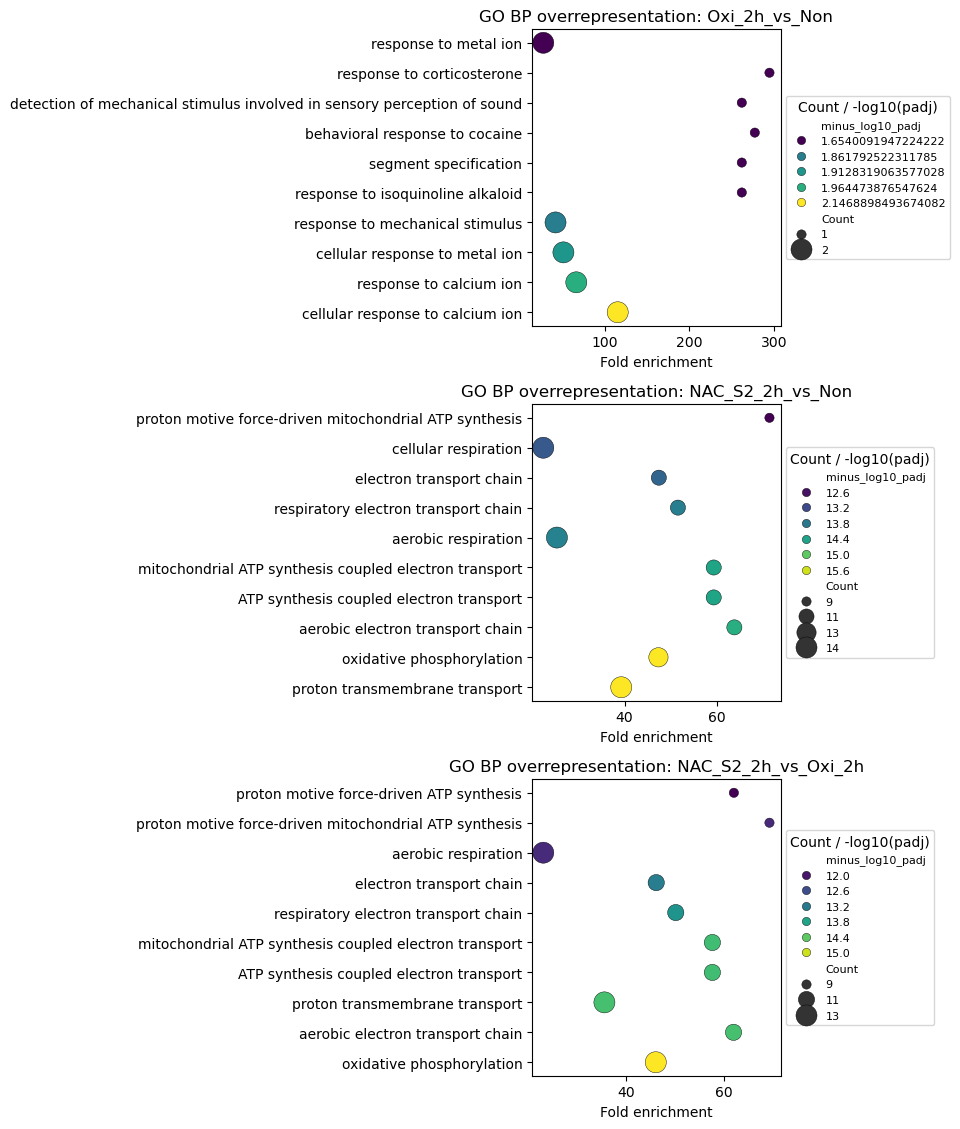

Wrote: results/report/go_bp_overrepresentation_dotplot.png


In [21]:
if ora_results.empty:
    print("No GO overrepresentation terms to plot. Run clusterProfiler first, or relax DEG thresholds if appropriate.")
else:
    ora_results = ora_results.copy()
    ora_results["minus_log10_padj"] = -np.log10(ora_results["p.adjust"].clip(lower=1e-300))
    contrasts_with_ora = [cid for cid in CONTRASTS["contrast_id"] if (ora_results["contrast_id"] == cid).any()]

    fig, axes = plt.subplots(
        nrows=len(contrasts_with_ora),
        ncols=1,
        figsize=(12, max(3.5, 3.8 * len(contrasts_with_ora))),
        squeeze=False,
    )

    for ax, contrast_id in zip(axes[:, 0], contrasts_with_ora):
        top_terms = (
            ora_results[ora_results["contrast_id"] == contrast_id]
            .sort_values("p.adjust")
            .head(TOP_ENRICHMENT_TERMS)
            .iloc[::-1]
        )
        sns.scatterplot(
            data=top_terms,
            x="FoldEnrichment",
            y="Description",
            size="Count",
            hue="minus_log10_padj",
            palette="viridis",
            sizes=(45, 230),
            edgecolor="black",
            linewidth=0.3,
            ax=ax,
        )
        ax.set_title(f"GO BP overrepresentation: {contrast_id}")
        ax.set_xlabel("Fold enrichment")
        ax.set_ylabel("")
        ax.legend(
            title="Count / -log10(padj)",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            fontsize=8,
            frameon=True,
        )

    plt.tight_layout(rect=(0, 0, 0.82, 1))
    out_path = REPORT_DIR / "go_bp_overrepresentation_dotplot.png"
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Wrote:", out_path.relative_to(PROJECT_DIR))


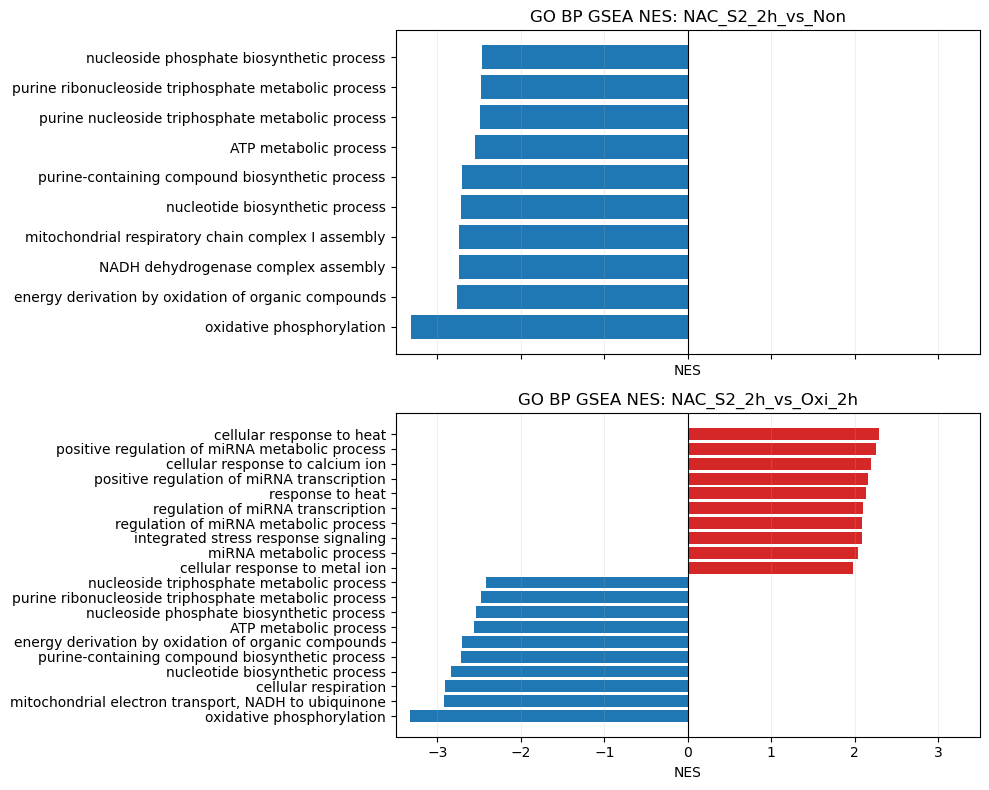

Wrote: results/report/go_bp_gsea_nes_barplot.png


In [26]:
if gsea_results.empty:
    print("No significant GSEA terms to plot. An empty GSEA file means no GO term passed the GSEA p-value cutoff.")
else:
    gsea_results = gsea_results.copy()
    gsea_results["minus_log10_padj"] = -np.log10(gsea_results["p.adjust"].clip(lower=1e-300))
    contrasts_with_gsea = [cid for cid in CONTRASTS["contrast_id"] if (gsea_results["contrast_id"] == cid).any()]

    gsea_plot_terms = []
    for contrast_id in contrasts_with_gsea:
        contrast_gsea = gsea_results[gsea_results["contrast_id"] == contrast_id]
        up_terms = contrast_gsea[contrast_gsea["NES"] > 0].sort_values("p.adjust").head(TOP_ENRICHMENT_TERMS)
        down_terms = contrast_gsea[contrast_gsea["NES"] < 0].sort_values("p.adjust").head(TOP_ENRICHMENT_TERMS)
        top_terms = pd.concat([down_terms, up_terms], ignore_index=True).sort_values("NES")
        if not top_terms.empty:
            gsea_plot_terms.append((contrast_id, top_terms))

    max_abs_nes = max(float(top_terms["NES"].abs().max()) for _, top_terms in gsea_plot_terms)
    nes_limit = np.ceil((max_abs_nes + 0.1) * 10) / 10

    fig, axes = plt.subplots(
        nrows=len(gsea_plot_terms),
        ncols=1,
        figsize=(10, max(3.5, 4.0 * len(gsea_plot_terms))),
        squeeze=False,
        sharex=True,
    )

    for ax, (contrast_id, top_terms) in zip(axes[:, 0], gsea_plot_terms):
        colors = np.where(top_terms["NES"] >= 0, "#d62728", "#1f77b4")
        ax.barh(top_terms["Description"], top_terms["NES"], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlim(-nes_limit, nes_limit)
        ax.grid(axis="x", alpha=0.2)
        ax.set_title(f"GO BP GSEA NES: {contrast_id}")
        ax.set_xlabel("NES")
        ax.set_ylabel("")
        """ax.text(
            0.01,
            0.02,
            "blue: reference-side enrichment, red: test-side enrichment",
            transform=ax.transAxes,
            fontsize=8,
            va="bottom",
        )"""

    plt.tight_layout()
    out_path = REPORT_DIR / "go_bp_gsea_nes_barplot.png"
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Wrote:", out_path.relative_to(PROJECT_DIR))


In [31]:
if gsea_results.empty:
    print("No significant GSEA terms to plot. An empty GSEA file means no GO term passed the GSEA p-value cutoff.")
else:
    gsea_results = gsea_results.copy()
    gsea_results["minus_log10_padj"] = -np.log10(gsea_results["p.adjust"].clip(lower=1e-300))
    contrasts_with_gsea = [cid for cid in CONTRASTS["contrast_id"] if (gsea_results["contrast_id"] == cid).any()]

    gsea_plot_terms = []
    for contrast_id in contrasts_with_gsea:
        contrast_gsea = gsea_results[gsea_results["contrast_id"] == contrast_id]
        print(contrast_gsea[["ID", "Description", "NES"]])

            ID                                        Description       NES
0   GO:0006119                          oxidative phosphorylation -3.318769
1   GO:0022904               respiratory electron transport chain -3.233203
2   GO:0042773           ATP synthesis coupled electron transport -3.214792
3   GO:0042775  mitochondrial ATP synthesis coupled electron t... -3.214792
4   GO:0019646                   aerobic electron transport chain -3.185026
5   GO:0022900                           electron transport chain -3.169190
6   GO:1902600                     proton transmembrane transport -3.117099
7   GO:0015986           proton motive force-driven ATP synthesis -3.084151
8   GO:0009145  purine nucleoside triphosphate biosynthetic pr... -3.077741
9   GO:0009206  purine ribonucleoside triphosphate biosyntheti... -3.066910
10  GO:0009201   ribonucleoside triphosphate biosynthetic process -3.053803
11  GO:0042776  proton motive force-driven mitochondrial ATP s... -3.046668
12  GO:00067

## report indexを作る

最後に、どこに何が出力されたかを1つのMarkdownにまとめる。


In [8]:
report_lines = [
    "# RNA-seq analysis report index",
    "",
    "## Route",
    f"- Route: `{ROUTE_NAME}`",
    f"- Quantification: `{ROUTE_QUANTIFICATION}`",
    "",
    "## Inputs",
    f"- Samples: `{CONFIG['samples_path']}`",
    f"- Contrasts: `{CONFIG['contrasts_path']}`",
    f"- Count matrix: `{ROUTE_COUNT_MATRIX}`",
    "",
    "## Main outputs",
    "- QC: `results/qc/`",
    f"- Quantification: `{ROUTE_QUANTIFICATION_OUTPUT}`",
    f"- Count matrix: `{ROUTE_COUNT_MATRIX}`",
    f"- Sample QC: `{ROUTE_SAMPLE_QC_DIR}`",
    f"- DESeq2: `{ROUTE_DE_DIR}`",
    f"- Report figures and DEG lists: `{ROUTE_REPORT_DIR}`",
    f"- Enrichment: `{ROUTE_ENRICHMENT_DIR}`",
    "",
    "## Contrasts",
]
for _, row in CONTRASTS.iterrows():
    report_lines.append(f"- `{row['contrast_id']}`: {row['description']}")

report_lines.extend(
    [
        "",
        "## Interpretation checklist",
        "- Check sample QC before trusting DEG lists.",
        "- Confirm log2 fold-change direction against the reference condition.",
        "- Treat enrichment as hypothesis generation, not final proof.",
    ]
)

report_path = REPORT_DIR / "report_index.md"
report_path.write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print(report_path.relative_to(PROJECT_DIR))


results/report/report_index.md


**よくある間違い**

- DEGリストだけを見て結論を急ぐ。
- pathway名だけを読んで、どの遺伝子が効いているか確認しない。
- `NAC_S2_2h_vs_Oxi_2h` のような比較で、log2 fold changeの向きを取り違える。

**小さい練習**

1つのcontrastについて、up gene上位10個とdown gene上位10個を見て、既知のストレス応答遺伝子が含まれるか確認しよう。
